# Straight Lines, Planes, Hyperplanes, and Point-to-Plane Distance

## Goal

Build the geometry used by linear classifiers such as logistic regression and Support Vector Machines (SVMs). You will learn:

- equivalent equations of a straight line;
- slope, intercept, coefficients, vectors, and dot products;
- the move from a 2D line to a 3D plane and an $n$-dimensional hyperplane;
- why the weight vector is perpendicular to the hyperplane;
- signed and ordinary distance from a point to a hyperplane;
- how the sign identifies the side of a decision boundary.

**Source material:** the supplied transcript and slides titled *Equation of a Straight Line, Hyperplane*. Repetition and video filler have been removed, and two notation slips in the spoken transcript are corrected explicitly.


## 1. Equation of a straight line

The familiar slope-intercept form is:

$$y = mx + c$$

- $m$ is the **slope**: change in $y$ for one unit of change in $x$.
- $c$ is the **$y$-intercept**: the value of $y$ when $x=0$.

The same pattern may use regression notation:

$$y = \beta_0 + \beta_1x$$

Here, $\beta_0=c$ and $\beta_1=m$.

The slope between two different points $(x_1,y_1)$ and $(x_2,y_2)$ is:

$$m=\frac{y_2-y_1}{x_2-x_1},\qquad x_2\ne x_1$$


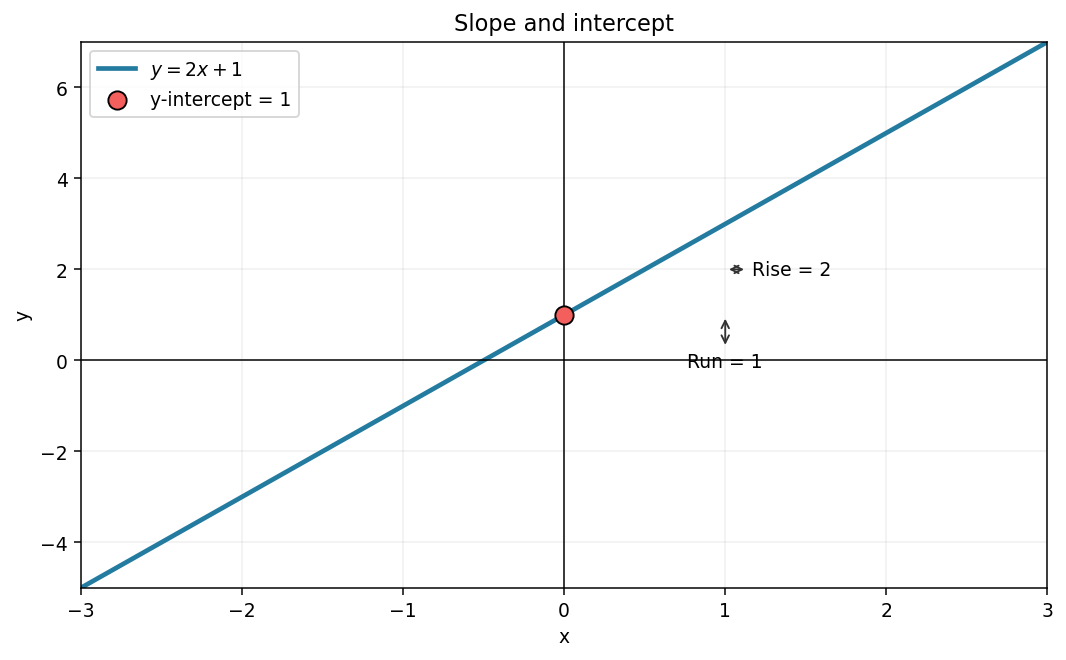

In [1]:
import numpy as np
import matplotlib.pyplot as plt

m = 2
c = 1
x = np.linspace(-3, 3, 200)
y = m * x + c

plt.figure(figsize=(8, 5))
plt.plot(x, y, linewidth=2.5, color="#247BA0", label=r"$y=2x+1$")
plt.scatter([0], [c], s=95, color="#F25F5C", edgecolor="black", zorder=3, label="y-intercept = 1")
plt.annotate("Run = 1", xy=(1, 1), xytext=(0, -28), textcoords="offset points",
             arrowprops=dict(arrowstyle="<->", color="#333333"), ha="center")
plt.annotate("Rise = 2", xy=(1, 2), xytext=(14, 0), textcoords="offset points",
             arrowprops=dict(arrowstyle="<->", color="#333333"), va="center")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlim(-3, 3)
plt.ylim(-5, 7)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Slope and intercept")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


For $y=2x+1$, moving one unit to the right increases $y$ by two. When $x=0$, $y=1$, so the line crosses the $y$-axis at $(0,1)$.

## 2. General form and its conversion

A 2D line can also be written as:

$$ax+by+c=0$$

If $b\ne0$, isolate $y$:

$$
by=-ax-c
$$

$$
y=-\frac{a}{b}x-\frac{c}{b}
$$

Therefore:

$$m=-\frac{a}{b},\qquad \text{$y$-intercept}=-\frac{c}{b}$$

The symbol names are arbitrary: the `b` in $ax+by+c=0$ is a coefficient, while the transcript later uses `b` as an intercept in vector notation. Always interpret a symbol from its equation.

**Special case:** if $b=0$, the equation becomes $ax+c=0$, or $x=-c/a$. This is a vertical line, so its slope is undefined and it cannot be written as $y=mx+c$.


In [2]:
# Example: 2x - y + 3 = 0  ->  y = 2x + 3
a, line_b, constant_c = 2, -1, 3
slope = -a / line_b
y_intercept = -constant_c / line_b
print("Slope:", slope)
print("y-intercept:", y_intercept)


Slope: 2.0
y-intercept: 3.0


## 3. Vector form in two dimensions

Rename the coordinates as $x_1$ and $x_2$ and the coefficients as $w_1$ and $w_2$:

$$w_1x_1+w_2x_2+b=0$$

Define column vectors:

$$
\mathbf{w}=\begin{bmatrix}w_1\\w_2\end{bmatrix},\qquad
\mathbf{x}=\begin{bmatrix}x_1\\x_2\end{bmatrix}
$$

Their dot product gives:

$$\mathbf{w}^T\mathbf{x}+b=0$$

This compact equation is extremely important in machine learning:

- $\mathbf{x}$ contains the input features;
- $\mathbf{w}$ contains their coefficients or **weights**;
- $b$ is the bias/intercept;
- $\mathbf{w}^T\mathbf{x}=\sum_i w_ix_i$ is a scalar.


In [3]:
w = np.array([2.0, -1.0])
point_on_line = np.array([1.0, 5.0])
bias = 3.0
value = w @ point_on_line + bias

print("w^T x + b =", value)
print("The point is on the line:", np.isclose(value, 0.0))


w^T x + b = 0.0
The point is on the line: True


## 4. From line to plane to hyperplane

The same equation changes its geometric name with the number of dimensions:

| Number of input dimensions | Boundary equation | Geometric object | Object's dimension |
|---:|---|---|---:|
| 2 | $w_1x_1+w_2x_2+b=0$ | line | 1 |
| 3 | $w_1x_1+w_2x_2+w_3x_3+b=0$ | plane | 2 |
| $n$ | $\sum_{i=1}^{n}w_ix_i+b=0$ | hyperplane | $n-1$ |

In every case, the compact form is:

$$\boxed{\mathbf{w}^T\mathbf{x}+b=0}$$

A **hyperplane** is therefore the higher-dimensional version of a line or plane. It divides the input space into two half-spaces when $\mathbf{w}\ne\mathbf{0}$.


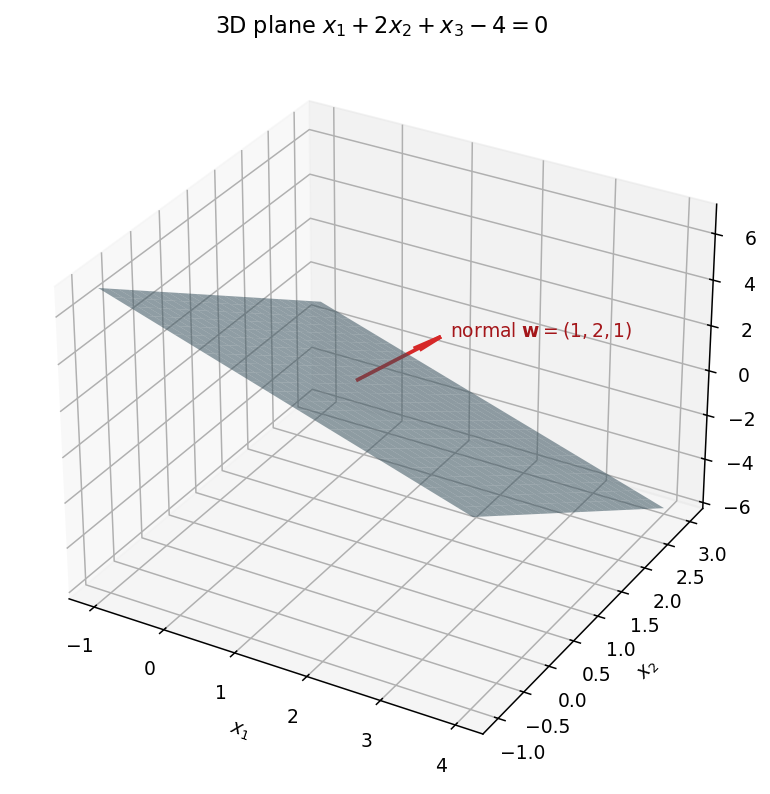

In [4]:
from mpl_toolkits.mplot3d import Axes3D  # registers the 3D projection

# Plane: x + 2y + z - 4 = 0  ->  z = 4 - x - 2y
grid_x, grid_y = np.meshgrid(np.linspace(-1, 4, 25), np.linspace(-1, 3, 25))
grid_z = 4 - grid_x - 2 * grid_y

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(grid_x, grid_y, grid_z, alpha=0.55, color="#8ECAE6", edgecolor="none")
ax.quiver(1, 1, 1, 1, 2, 1, length=1.2, normalize=True, color="#D62828", linewidth=2)
ax.text(1.6, 2.0, 1.6, r"normal $\mathbf{w}=(1,2,1)$", color="#A4161A")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$x_3$")
ax.set_title(r"3D plane $x_1+2x_2+x_3-4=0$")
plt.tight_layout()
plt.show()


## 5. A hyperplane through the origin

The origin is the all-zero point: $\mathbf{0}=(0,0,\ldots,0)$.

Substitute $\mathbf{x}=\mathbf{0}$ into the hyperplane equation:

$$\mathbf{w}^T\mathbf{0}+b=b$$

So the hyperplane passes through the origin exactly when:

$$b=0$$

Its equation then becomes:

$$\boxed{\mathbf{w}^T\mathbf{x}=0}$$

If $b\ne0$, the hyperplane is shifted away from the origin.


## 6. Dot product and the normal vector

For non-zero vectors $\mathbf{w}$ and $\mathbf{x}$:

$$
\mathbf{w}^T\mathbf{x}=\|\mathbf{w}\|\,\|\mathbf{x}\|\cos\theta
$$

where $\theta$ is the angle between them and $\|\cdot\|$ is Euclidean magnitude.

If a hyperplane passes through the origin, every point vector $\mathbf{x}$ on it satisfies $\mathbf{w}^T\mathbf{x}=0$. With non-zero vectors, this means $\cos\theta=0$ and $\theta=90^\circ$. Therefore:

$$\boxed{\mathbf{w}\text{ is perpendicular to the hyperplane}}$$

$\mathbf{w}$ is called the **normal vector**. The spoken transcript briefly says “parallel,” but its equation and later explanation show the correct relationship: **perpendicular**.

For a shifted hyperplane ($b\ne0$), the position vector of a point on the plane is not necessarily perpendicular to $\mathbf{w}$. Instead, the difference between any two points on the plane is perpendicular to $\mathbf{w}$.


In [5]:
w = np.array([3.0, 4.0])
x_on_origin_line = np.array([4.0, -3.0])

dot_product = w @ x_on_origin_line
norm_w = np.linalg.norm(w)
norm_x = np.linalg.norm(x_on_origin_line)
angle_degrees = np.degrees(np.arccos(np.clip(dot_product / (norm_w * norm_x), -1, 1)))

print("Dot product:", dot_product)
print("Angle:", round(angle_degrees, 1), "degrees")


Dot product: 0.0
Angle: 90.0 degrees


## 7. Distance from a point to a hyperplane

Let the hyperplane be:

$$\mathbf{w}^T\mathbf{x}+b=0$$

and let $\mathbf{s}$ be any point. The **signed perpendicular distance** is:

$$
d_{\text{signed}}=\frac{\mathbf{w}^T\mathbf{s}+b}{\|\mathbf{w}\|}
$$

The ordinary geometric distance cannot be negative, so it is:

$$
d=\frac{|\mathbf{w}^T\mathbf{s}+b|}{\|\mathbf{w}\|}
$$

If the hyperplane passes through the origin, $b=0$, and these reduce to the transcript's form:

$$d_{\text{signed}}=\frac{\mathbf{w}^T\mathbf{s}}{\|\mathbf{w}\|}$$

The numerator measures displacement in the normal direction. Division by $\|\mathbf{w}\|$ removes the arbitrary scale of the equation. Multiplying the whole equation by 10 should not make the geometric distance ten times larger.


In [6]:
def signed_distance(point, weights, bias):
    point = np.asarray(point, dtype=float)
    weights = np.asarray(weights, dtype=float)
    if np.allclose(weights, 0):
        raise ValueError("weights must not be the zero vector")
    return (weights @ point + bias) / np.linalg.norm(weights)


weights = np.array([3.0, 4.0])
bias = -10.0
points = {
    "A (positive side)": np.array([4.0, 2.0]),
    "B (on boundary)": np.array([2.0, 1.0]),
    "C (negative side)": np.array([0.0, 0.0]),
}

for name, point in points.items():
    signed = signed_distance(point, weights, bias)
    print(f"{name:18s} signed = {signed:5.2f}, ordinary distance = {abs(signed):5.2f}")


A (positive side)  signed =  2.00, ordinary distance =  2.00
B (on boundary)    signed =  0.00, ordinary distance =  0.00
C (negative side)  signed = -2.00, ordinary distance =  2.00


For the line $3x+4y-10=0$, $\|\mathbf{w}\|=\sqrt{3^2+4^2}=5$.

- Point A $(4,2)$: $(12+8-10)/5=+2$.
- Point B $(2,1)$: $(6+4-10)/5=0$; it lies on the line.
- Point C $(0,0)$: $-10/5=-2$.

A negative signed distance is not a negative physical length. It simply means the point is on the side opposite the direction of $\mathbf{w}$. If we replace $(\mathbf{w},b)$ with $(-\mathbf{w},-b)$, the same hyperplane is described but every sign flips.


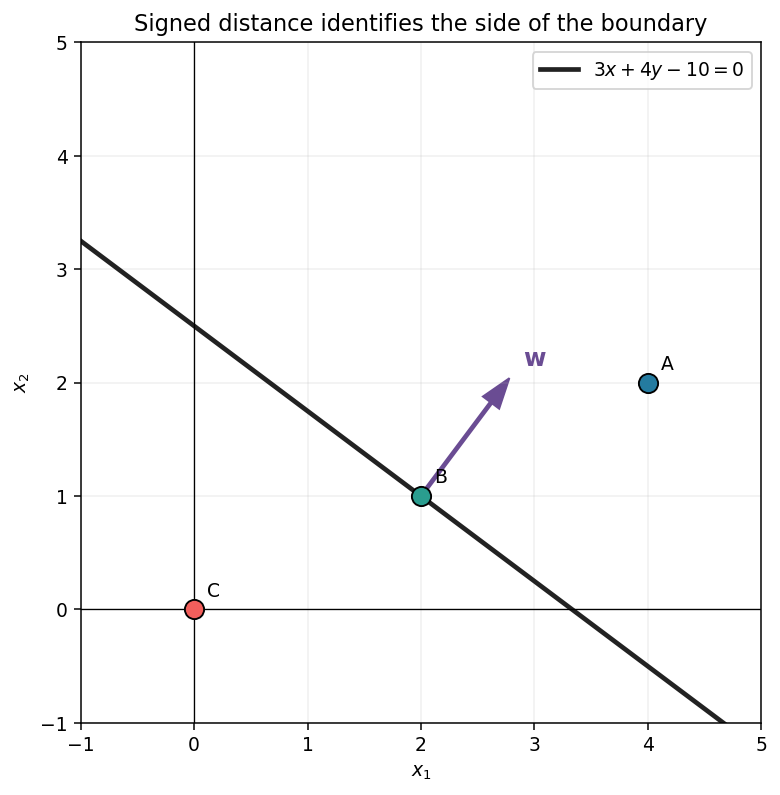

In [7]:
# Visualize the boundary, its normal direction, and the three points
x_vals = np.linspace(-1, 5, 300)
y_vals = (10 - 3 * x_vals) / 4

plt.figure(figsize=(8, 6))
plt.plot(x_vals, y_vals, color="#222222", linewidth=2.5, label=r"$3x+4y-10=0$")

point_colors = ["#247BA0", "#2A9D8F", "#F25F5C"]
for (name, point), color in zip(points.items(), point_colors):
    plt.scatter(*point, s=105, color=color, edgecolor="black", zorder=4)
    plt.annotate(name.split()[0], point, xytext=(7, 7), textcoords="offset points")

# A normal arrow beginning on the boundary point B
base = points["B (on boundary)"]
unit_normal = weights / np.linalg.norm(weights)
plt.arrow(base[0], base[1], unit_normal[0] * 1.3, unit_normal[1] * 1.3,
          width=0.025, head_width=0.18, color="#6A4C93", length_includes_head=True)
plt.text(base[0] + 0.9, base[1] + 1.15, r"$\mathbf{w}$", color="#6A4C93", fontsize=13)

plt.axhline(0, color="black", linewidth=0.7)
plt.axvline(0, color="black", linewidth=0.7)
plt.xlim(-1, 5)
plt.ylim(-1, 5)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Signed distance identifies the side of the boundary")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


## 8. A short derivation of the distance formula

Take a point $\mathbf{x}_0$ on the hyperplane, so $\mathbf{w}^T\mathbf{x}_0+b=0$. The unit normal is:

$$\hat{\mathbf{w}}=\frac{\mathbf{w}}{\|\mathbf{w}\|}$$

The signed projection of the displacement $\mathbf{s}-\mathbf{x}_0$ onto the normal is:

$$
(\mathbf{s}-\mathbf{x}_0)^T\hat{\mathbf{w}}
=\frac{\mathbf{w}^T\mathbf{s}-\mathbf{w}^T\mathbf{x}_0}{\|\mathbf{w}\|}
$$

Because $\mathbf{w}^T\mathbf{x}_0=-b$:

$$
d_{\text{signed}}=\frac{\mathbf{w}^T\mathbf{s}+b}{\|\mathbf{w}\|}
$$

Taking the absolute value gives ordinary distance.


## 9. Connection to machine learning

### Linear classification score

Many classifiers begin with:

$$z=\mathbf{w}^T\mathbf{x}+b$$

- $z>0$: one side of the boundary;
- $z<0$: the other side;
- $z=0$: exactly on the decision boundary.

### Logistic regression

Logistic regression transforms $z$ using the sigmoid:

$$P(y=1\mid\mathbf{x})=\frac{1}{1+e^{-z}}$$

At the usual probability threshold $0.5$, $z=0$, so the decision boundary is $\mathbf{w}^T\mathbf{x}+b=0$.

### Support Vector Machine

A linear SVM also uses $\mathbf{w}^T\mathbf{x}+b$. It chooses a separating hyperplane while controlling the **margin**, which is based on perpendicular distances to the boundary. This is why the point-to-hyperplane formula matters.


In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

for z in [-4, -1, 0, 1, 4]:
    print(f"z={z:>2}: probability={sigmoid(z):.3f}")


z=-4: probability=0.018
z=-1: probability=0.269
z= 0: probability=0.500
z= 1: probability=0.731
z= 4: probability=0.982


## 10. Common mistakes

1. **Calling signed distance an ordinary distance.** Ordinary distance uses an absolute value and is never negative.
2. **Forgetting `b`.** The formula $\mathbf{w}^T\mathbf{s}/\|\mathbf{w}\|$ is valid only when the hyperplane passes through the origin.
3. **Saying the normal is parallel to the plane.** It is perpendicular to every direction lying within the plane.
4. **Assuming the sign is permanent.** Reversing $\mathbf{w}$ and $b$ reverses the sign but leaves the boundary unchanged.
5. **Forgetting to divide by $\|\mathbf{w}\|$.** The raw score gives the side but is not a scale-independent geometric distance.
6. **Confusing the object's dimension with the surrounding space.** A hyperplane in $n$-dimensional space has dimension $n-1$.
7. **Trying to write every line as $y=mx+c$.** Vertical lines require the general form.


## 11. Quick revision sheet

| Concept | Formula / meaning |
|---|---|
| Slope-intercept line | $y=mx+c$ |
| General 2D line | $ax+by+c=0$ |
| Vector hyperplane | $\mathbf{w}^T\mathbf{x}+b=0$ |
| Through origin | $b=0$, so $\mathbf{w}^T\mathbf{x}=0$ |
| Dot product | $\mathbf{w}^T\mathbf{x}=\|\mathbf{w}\|\|\mathbf{x}\|\cos\theta$ |
| Normal vector | $\mathbf{w}$; perpendicular to the hyperplane |
| Signed distance | $(\mathbf{w}^T\mathbf{s}+b)/\|\mathbf{w}\|$ |
| Ordinary distance | $|\mathbf{w}^T\mathbf{s}+b|/\|\mathbf{w}\|$ |
| Positive/negative score | Two opposite half-spaces |
| On the boundary | Score and signed distance are both zero |


## 12. Quick questions — try before opening the answers

1. In $y=mx+c$, what do $m$ and $c$ represent?
2. Convert $ax+by+c=0$ to slope-intercept form when $b\ne0$.
3. Why can a vertical line not be written as $y=mx+c$?
4. Write $w_1x_1+w_2x_2+b=0$ in vector notation.
5. What geometric object does one linear equation describe in 2D, 3D, and $n$D?
6. What condition makes a hyperplane pass through the origin?
7. Why is $\mathbf{w}$ called the normal vector?
8. What is the difference between signed distance and ordinary distance?
9. Why do we divide by $\|\mathbf{w}\|$ in the distance formula?
10. What does a negative signed distance mean?
11. For $3x+4y-10=0$, find the signed distance of $(4,2)$.
12. What is the signed distance of a point lying on the hyperplane?
13. If $(\mathbf{w},b)$ is replaced by $(-\mathbf{w},-b)$, what changes?
14. What is the logistic-regression probability when $\mathbf{w}^T\mathbf{x}+b=0$?
15. How is this geometry used by a linear SVM?


## 13. Answer key

1. $m$ is slope and $c$ is the $y$-intercept.
2. $y=-(a/b)x-c/b$.
3. Its change in $x$ is zero, so the slope would require division by zero; the slope is undefined.
4. $\mathbf{w}^T\mathbf{x}+b=0$.
5. A line in 2D, a plane in 3D, and an $(n-1)$-dimensional hyperplane in $n$D.
6. $b=0$.
7. It is perpendicular to every direction within the hyperplane.
8. Signed distance includes the side as a sign; ordinary distance is its absolute value and cannot be negative.
9. To normalize the equation, making the result independent of the scale of $\mathbf{w}$ and equal to geometric distance.
10. The point is on the side opposite the chosen direction of $\mathbf{w}$; it does not mean negative physical length.
11. $(3\cdot4+4\cdot2-10)/5=2$.
12. Zero.
13. The hyperplane and ordinary distances stay the same, while all signed scores/distances reverse sign.
14. $0.5$, because the sigmoid of zero is $1/2$.
15. The SVM chooses a separating hyperplane and uses perpendicular distances to define and maximize its margin.
